In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import torch
import torch.nn as nn

# Exercise 5 - PINN

## Task 1)

We use the same exact solution, used to verify convergence in exercise 2, task 5, for veriyfing the output from our PINN

In this task we will make a PINN that can solve the one-dimensional unsteady heat diffusion problem.

We use a network architecture where we have layers of Linear and Tanh activation with a chosen amount of hidden nodes and the number of layers also customizable. The last layer is a linear layer with one output feature.

For our loss function we compute the loss for the pde, the bc and the ic, the total loss is then the sum of these where we apply some custom weights for all three terms, here we use 1 for the ic, bc and pde to start, but after 1000 epochs we apply a weight of 2 to the pde loss

We use the Adam optimizer to train the model and finish with LBFGS for a maximum of 2000 iterations, this further reduces the error compared to the exact solution

The network can be written as:
$$
\mathcal{N}(x, t) = \bigl(L_{d+1} \circ \tanh \circ L_d \circ \cdots \circ \tanh \circ L_1\bigr)\!\begin{pmatrix}x\\t\end{pmatrix}
$$

where $L_k(\mathbf{z}) = W^{(k)}\mathbf{z} + \mathbf{b}^{(k)}$ are affine maps, $d$ is the number of hidden layers, and the final layer $L_{d+1}$ has a single output neuron with no activation.


In [ ]:
epsilon = 0.1
T = 0.1

# NumPy version for reference / FTCS comparison
def exact_solution(x, t):
    return (
        np.exp(-epsilon * t) * np.cos(x)
        + np.exp(-16 * epsilon * t) * np.cos(4*x)
        + np.exp(-256 * epsilon * t) * np.cos(16*x)
    )

# Torch version needed for supervised IC/BC losses
def exact_solution_torch(x, t):
    return (
        torch.exp(-epsilon * t) * torch.cos(x)
        + torch.exp(-16 * epsilon * t) * torch.cos(4*x)
        + torch.exp(-256 * epsilon * t) * torch.cos(16*x)
    )

def solve_ftcs(N):
    h = 2 / N

    # Choosing k according to stability condition
    k = 0.4 * h**2 / epsilon
    M = int(np.ceil(T / k))
    k = T / M

    x = np.linspace(-1, 1, N+1)
    u = exact_solution(x, 0)

    mu = epsilon * k / h**2

    Us = []

    for n in range(M):
        t_next = (n+1) * k
        u_new = u.copy()

        u_new[1:-1] = (
            u[1:-1]
            + mu * (u[2:] - 2*u[1:-1] + u[:-2])
        )

        # Dirichlet boundary values
        u_new[0] = exact_solution(-1, t_next)
        u_new[-1] = exact_solution(1, t_next)

        u = u_new
        Us.append(u.copy())

    error = np.max(np.abs(u - exact_solution(x, T)))
    return h, k, error, Us


class HeatDiffPINN(nn.Module):
    def __init__(self, hidden: int = 40, layers: int = 4):
        super().__init__()
        modules = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(layers - 1):
            modules += [nn.Linear(hidden, hidden), nn.Tanh()]
        modules.append(nn.Linear(hidden, 1))
        self.net = nn.Sequential(*modules)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

    def pde_residual(self, x, t):
        """Compute residual r = u_t - epsilon * u_xx at (x,t).
        x and t must have requires_grad=True.
        """
        u = self.forward(x, t)
        u_t  = torch.autograd.grad(u,   t,  torch.ones_like(u),   create_graph=True)[0]
        u_x  = torch.autograd.grad(u,   x,  torch.ones_like(u),   create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x,  torch.ones_like(u_x), create_graph=True)[0]
        return u_t - epsilon * u_xx


def train_pinn(model, epochs=5000, lr=1e-3, n_colloc=2000, n_bc=200, n_ic=200):
    loss_history: dict = {"total": [], "lbfgs": []}

    # Helper functions to calculate derivatives
    def grad(outputs, inputs):
        return torch.autograd.grad(outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True, retain_graph=True)[0]

    def compute_loss(epoch):
        """Recompute the full loss from fresh samples (required for LBFGS closure)."""
        x_col = (torch.rand(n_colloc, 1) * 2 - 1).requires_grad_(True)
        t_col = (torch.rand(n_colloc, 1) * T).requires_grad_(True)
        loss_pde = torch.mean(model.pde_residual(x_col, t_col)**2)

        x_ic = torch.rand(n_ic, 1) * 2 - 1
        t_ic = torch.zeros(n_ic, 1)
        loss_ic = torch.mean((model(x_ic, t_ic) - exact_solution_torch(x_ic, t_ic))**2)

        t_bc = torch.rand(n_bc, 1) * T
        x_left  = -torch.ones(n_bc, 1)
        x_right =  torch.ones(n_bc, 1)
        loss_bc = (
            torch.mean((model(x_left,  t_bc) - exact_solution_torch(x_left,  t_bc))**2)
          + torch.mean((model(x_right, t_bc) - exact_solution_torch(x_right, t_bc))**2)
        )
    
        w_bc = 1.0
        w_ic = 1.0
        w_pde = 1 + (epoch > 1000)

        return w_pde * loss_pde + w_ic * loss_ic + w_bc * loss_bc

    # --- Phase 1: Adam ---
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = compute_loss(epoch)
        loss.backward()
        optimizer.step()

        loss_history["total"].append(loss.item())

        if epoch % 500 == 0:
            print(f"Epoch {epoch:5d} | total={loss.item():.3e}")

    # --- Phase 2: LBFGS fine-tuning (after Adam) ---
    opt_lbfgs = torch.optim.LBFGS(
        model.parameters(), lr=1.0, max_iter=2000,
        history_size=50, line_search_fn="strong_wolfe",
    )

    def closure():
        opt_lbfgs.zero_grad()
        loss = compute_loss(epochs)
        loss.backward()
        loss_history["lbfgs"].append(loss.item())
        n = len(loss_history["lbfgs"])
        if n % 200 == 0 or n == 1:
            print(f"[LBFGS] iter {n:4d}  loss={loss.item():.3e}", end="\r")
        return loss

    opt_lbfgs.step(closure)
    print(f"\n[LBFGS] final={loss_history['lbfgs'][-1]:.3e} "
          f"({len(loss_history['lbfgs'])} iters)")

    return loss_history


# --- Run ---
EPOCHS = 30000
N_FIN = 100
N_PINN = 1000


# Finite difference reference
h, k, fd_error, Us = solve_ftcs(N_FIN)
print(f"FTCS: h={h:.4f}, k={k:.6f}, max error={fd_error:.3e}\n")

# Train PINN
pinn = HeatDiffPINN(hidden=30, layers=3)
loss_history = train_pinn(pinn, epochs=EPOCHS)

# Evaluate on a fine grid at t = T
x_eval = torch.linspace(-1, 1, N_PINN).unsqueeze(1)
t_eval = torch.full((N_PINN, 1), T)
with torch.no_grad():
    u_pinn = pinn(x_eval, t_eval).squeeze().numpy()
u_exact = exact_solution(x_eval.numpy(), T)

pinn_error = np.max(np.abs(u_pinn - u_exact.squeeze()))
print(f"\nPINN max error at t={T}: {pinn_error:.3e}")
print(f"FTCS max error at t={T}: {fd_error:.3e}")

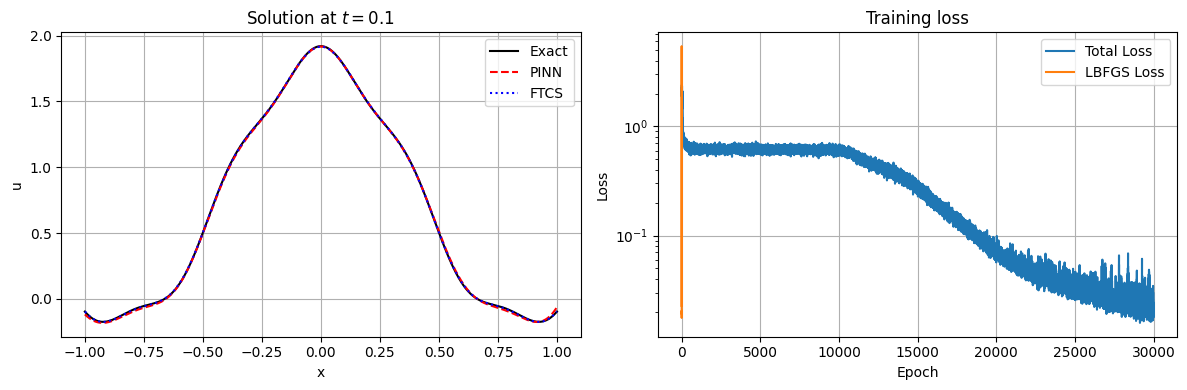

In [31]:
# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_eval.numpy(), u_exact, 'k-', label='Exact')
axes[0].plot(x_eval.numpy(), u_pinn,  'r--', label='PINN')
axes[0].plot(np.linspace(-1, 1, N_FIN+1), Us[-1], 'b:', label='FTCS')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u')
axes[0].set_title(rf'Solution at $t={T}$')
axes[0].legend(); axes[0].grid()

axes[1].semilogy(loss_history["total"], label="Total Loss")
axes[1].semilogy(loss_history["lbfgs"], label="LBFGS Loss")
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training loss'); axes[1].legend(); axes[1].grid()

plt.tight_layout()
plt.show()  

We see that the PINN does not perform as well as the numerical FTCS solver, where the error is much lower than the error on the PINN.

We observe that the PINN is not as accurate near the boundaries as the FTCS solver, but that it can indeed find the solution given enough epochs. In order to get this accuracy with the PINN, we used 30000 epochs and evaluated on 1000 grid points, this is 10 times the grid points used for the FTCS solver, which also runs much faster than the PINN solution.

In this case a PINN is not the smarter choice between a numerical solver and the PINN, however, as a proof of concept we can see that a PINN can indeed find the solution to a 1D heat equation